# Student Performance — End-to-End Regression Walkthrough

**Dataset:** UCI "Student Performance" (Math course), Cortez & Silva, 2008 — 395 students, 33 columns.

**Goal:** predict a student's final grade `G3` (0–20), and understand *why* the model
predicts what it does, using a full, honest regression workflow:

1. Data understanding & exploratory data analysis (EDA)
2. Feature engineering & preprocessing (no data leakage)
3. Feature selection
4. Model comparison across 9 regression algorithms + hyperparameter tuning
5. Held-out test evaluation (two different problem framings — Scenario A vs Scenario B)
6. Formal OLS regression-assumption diagnostics (linearity, normality, homoscedasticity,
   multicollinearity, independence, influential points)

> **How to use this notebook in class:** run the cells top to bottom, in order — each
> section builds on variables created in the previous one. Markdown cells explain the
> *why* before each code cell shows the *how*. Pause after each section's plots to
> discuss what the chart is telling us before moving on.


## Problem framing: two scenarios, not one

`G1` and `G2` (grades from the first two grading periods) are *extremely* strong
predictors of `G3` (r ≈ 0.80 and 0.90) — because they're basically the same
measurement taken earlier in the year. That creates two genuinely different
prediction problems, and we will build both:

| | **Scenario A** — with prior grades | **Scenario B** — early prediction |
|---|---|---|
| Features | demographics + behaviour **+ G1, G2** | demographics + behaviour only |
| Question answered | "How will this student finish the year?" | "Who is at risk, before any grade exists?" |
| Expected difficulty | Easy — G1/G2 do most of the work | Hard — the real ML problem |

Reporting only Scenario A's R² would be misleading (it looks great mostly because
G2 leaks most of the answer). Reporting only Scenario B's R² would undersell how
useful grades-in-progress are for tracking students later in the term. **Always
report both.**


## 0. Setup

Standard data-science stack: `pandas`/`numpy` for data handling, `matplotlib` for
plotting, `scikit-learn` for the ML pipeline, `scipy`/`statsmodels` for the formal
statistical tests later in the notebook.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, linear_rainbow
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

RANDOM_STATE = 42   # fixed everywhere so results are reproducible

# A simple, readable plot style (swap for your own house style if you like)
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10.5, "axes.titlesize": 12, "axes.titleweight": "bold", "figure.dpi": 100,
})

print("Setup complete.")


Setup complete.


## 1. Load & inspect the data

The raw file is semicolon-separated (`sep=";"` — a common trap with UCI datasets).


In [2]:
DATA = "../data/student-mat.csv"
df = pd.read_csv(DATA, sep=";")

print("Shape:", df.shape)
df.head()


Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [4]:
# Data quality checks — always do this before anything else
missing_total = int(df.isna().sum().sum())
duplicates = int(df.duplicated().sum())
print(f"Missing values: {missing_total}")
print(f"Duplicate rows: {duplicates}")

# A clean dataset like this one is the exception, not the rule — in real projects
# you would branch here into imputation / deduplication logic.


Missing values: 0
Duplicate rows: 0


### Attribute dictionary (abridged)

| Column | Meaning |
|---|---|
| `school`, `sex`, `age`, `address`, `famsize`, `Pstatus` | demographics |
| `Medu`, `Fedu`, `Mjob`, `Fjob` | parental education (0–4) & job (nominal) |
| `reason`, `guardian`, `traveltime`, `studytime` | school context |
| `failures` | number of past class failures (0–4) |
| `schoolsup`, `famsup`, `paid`, `activities`, `nursery`, `higher`, `internet`, `romantic` | yes/no support & lifestyle flags |
| `famrel`, `freetime`, `goout`, `Dalc`, `Walc`, `health` | 1–5 self-rated scales |
| `absences` | school absences (0–93) |
| `G1`, `G2`, `G3` | period 1, period 2, and final grade (0–20) — **`G3` is the target** |

Full dictionary: [`data/student.txt`](../data/student.txt).


## 2. Exploring the target: `G3`

Always understand your target variable's distribution before modeling — it tells
you what kind of errors to expect and whether the mean/median are even meaningful
summaries.


count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

Students scoring exactly 0: 38 (9.62%)


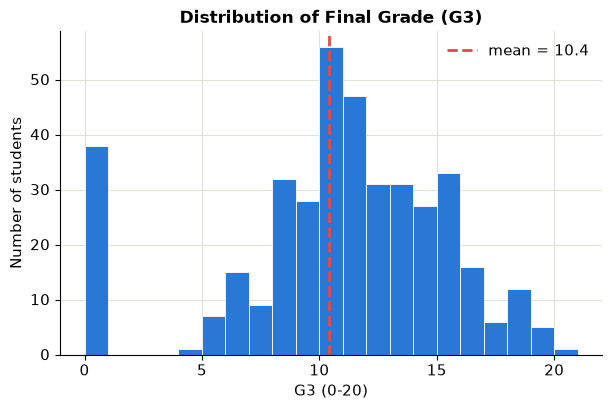

In [5]:
target_stats = df["G3"].describe()
zero_g3 = int((df["G3"] == 0).sum())
pct_zero = round(100 * (df["G3"] == 0).mean(), 2)

print(target_stats)
print(f"\nStudents scoring exactly 0: {zero_g3} ({pct_zero}%)")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.hist(df["G3"], bins=range(0, 22), color=CAT[0], edgecolor="white", linewidth=0.6)
ax.axvline(df["G3"].mean(), color=CAT[7], linestyle="--", linewidth=2,
           label=f"mean = {df['G3'].mean():.1f}")
ax.set_title("Distribution of Final Grade (G3)")
ax.set_xlabel("G3 (0-20)"); ax.set_ylabel("Number of students")
ax.legend(frameon=False)
plt.show()


**Talking point for class:** notice the spike at `G3 = 0`. The original study
(Cortez & Silva) attributes this to exam **withdrawal**, not genuine failure —
those students never sat the final exam. This single fact will resurface later
when our OLS assumption checks fail, and again when we discuss what to do about
it (a two-stage "hurdle" model).


### G1 → G2 → G3: why this is really two problems

`G1` and `G2` are the same underlying measurement, taken earlier. If we include
them as features, the model barely has to "learn" anything — it just extrapolates
the trend. This is exactly the leakage-like effect that motivates Scenario A vs B.


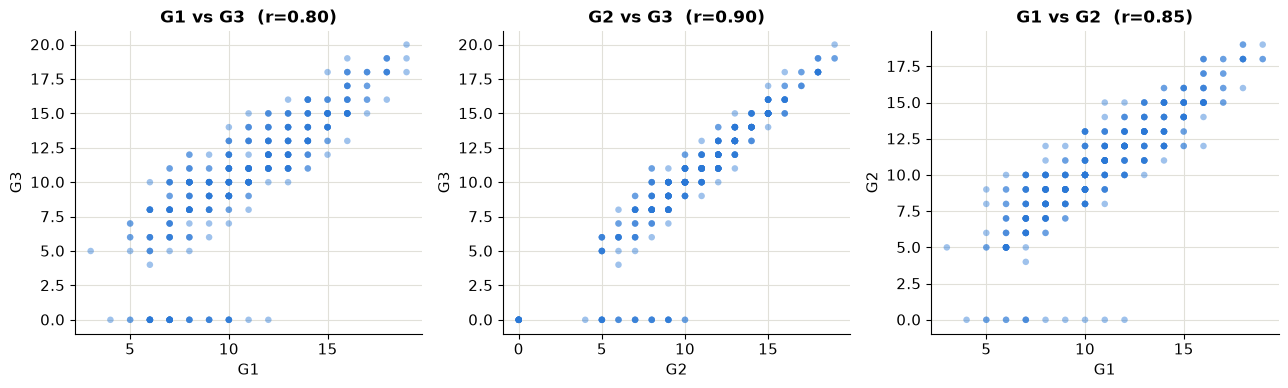

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (x, y) in zip(axes, [("G1", "G3"), ("G2", "G3"), ("G1", "G2")]):
    ax.scatter(df[x], df[y], alpha=0.45, s=22, color=CAT[0], edgecolor="none")
    r = df[x].corr(df[y])
    ax.set_title(f"{x} vs {y}  (r={r:.2f})")
    ax.set_xlabel(x); ax.set_ylabel(y)
plt.tight_layout(); plt.show()


## 3. Full correlation heatmap

A quick way to scan for the strongest linear relationships across *all* numeric
columns at once, and to spot pairs of features that might be collinear.


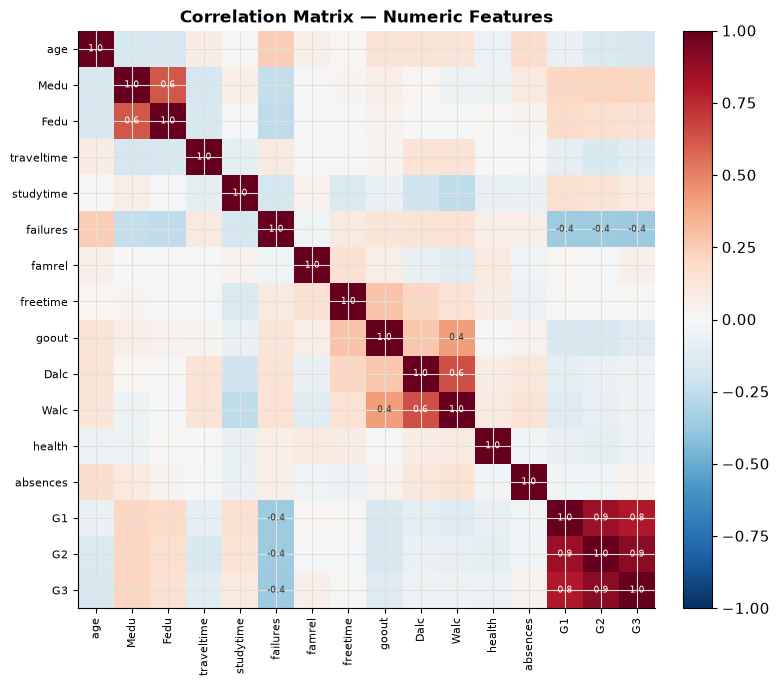

Top correlations with G3:
G2            0.905
G1            0.801
failures     -0.360
Medu          0.217
age          -0.162
Fedu          0.152
goout        -0.133
traveltime   -0.117
studytime     0.098
health       -0.061
Dalc         -0.055
Walc         -0.052
famrel        0.051
absences      0.034
freetime      0.011
Name: G3, dtype: float64


In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols))); ax.set_xticklabels(numeric_cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(numeric_cols))); ax.set_yticklabels(numeric_cols, fontsize=8)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        v = corr.iloc[i, j]
        if abs(v) >= 0.3:
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=6.5,
                    color="white" if abs(v) > 0.6 else "#333")
ax.set_title("Correlation Matrix — Numeric Features")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

corr_with_target = corr["G3"].drop("G3").sort_values(key=lambda s: -s.abs())
print("Top correlations with G3:")
print(corr_with_target.round(3))


**Talking point:** after `G1`/`G2`, `failures` is the strongest single predictor
(negative — more past failures, lower final grade). Everything else is weak in
isolation (|r| < 0.25) — a hint that Scenario B will be genuinely hard, and that
non-linear interactions (which a single correlation coefficient can't see) may
matter more than any one variable.


## 4. Categorical breakdowns vs G3

Mean `G3` grouped by a few key categorical attributes.


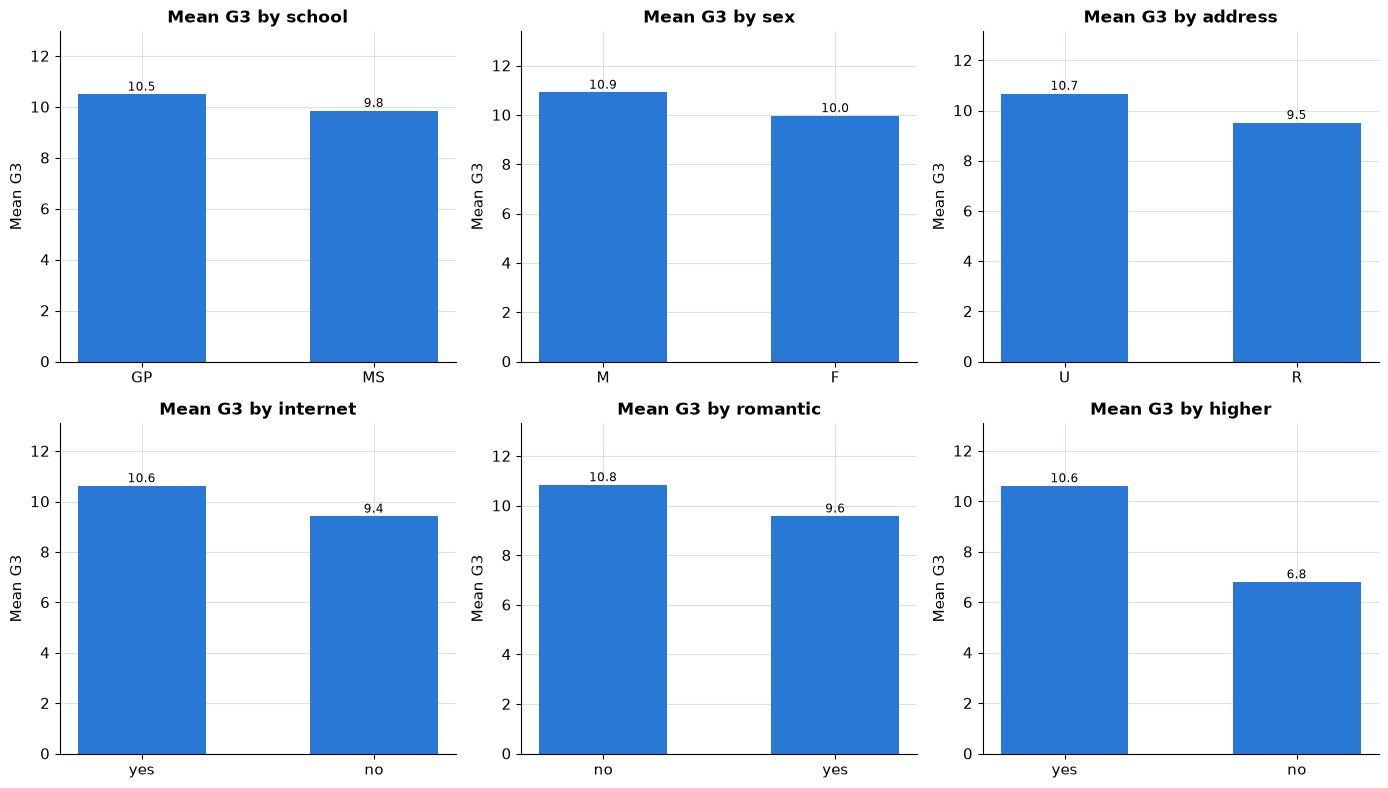

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
cat_specs = ["school", "sex", "address", "internet", "romantic", "higher"]
for ax, col in zip(axes.flat, cat_specs):
    groups = df.groupby(col)["G3"].mean().sort_values(ascending=False)
    bars = ax.bar(groups.index.astype(str), groups.values, color=CAT[0], width=0.55)
    ax.set_title(f"Mean G3 by {col}"); ax.set_ylabel("Mean G3")
    for b, v in zip(bars, groups.values):
        ax.text(b.get_x() + b.get_width()/2, v + 0.15, f"{v:.1f}", ha="center", fontsize=8.5)
    ax.set_ylim(0, max(groups.values) + 2.5)
plt.tight_layout(); plt.show()


## 5. Key numeric drivers vs G3 (boxplots)

Boxplots reveal ordinal relationships that a single correlation number can hide —
e.g. does grade fall off a cliff after just 1 failure, or decline gradually?


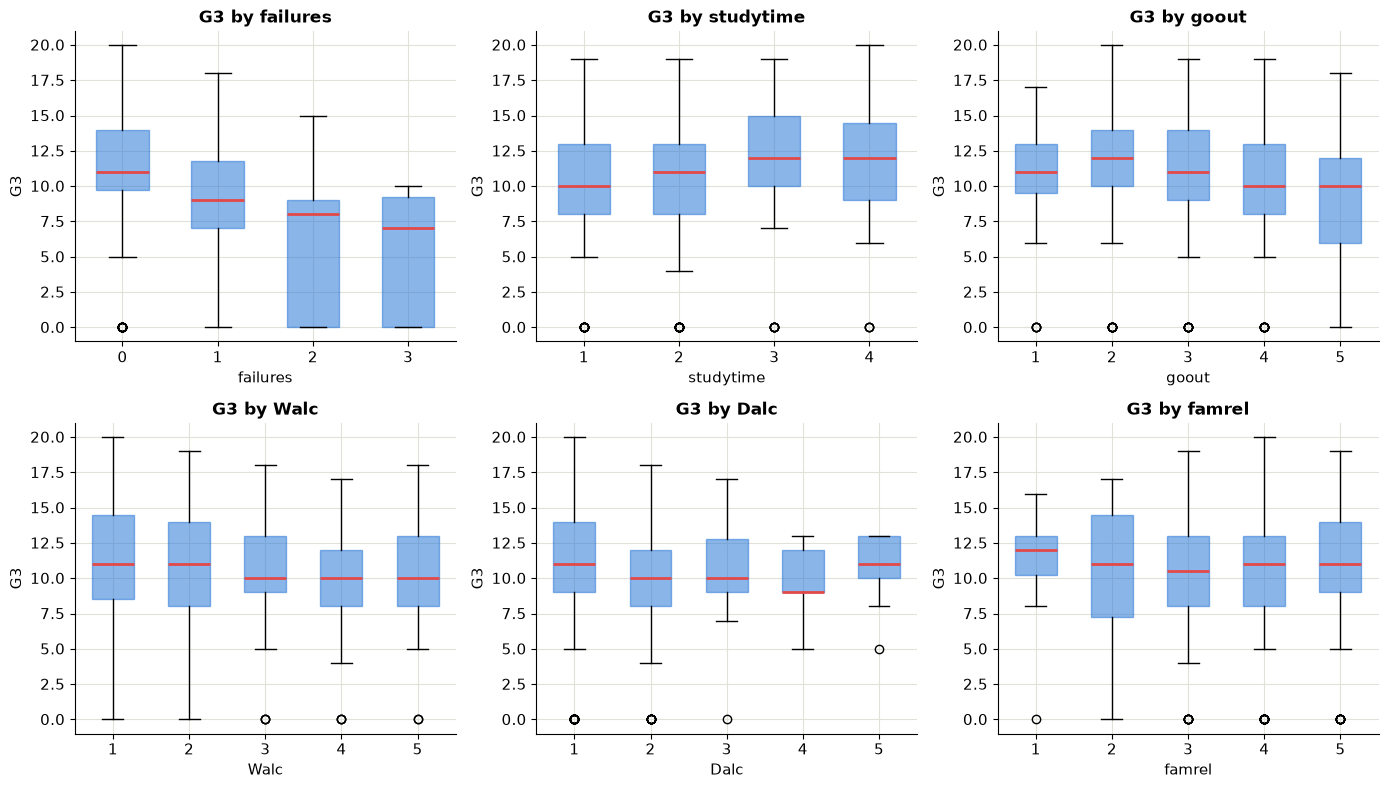

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
box_specs = ["failures", "studytime", "goout", "Walc", "Dalc", "famrel"]
for ax, col in zip(axes.flat, box_specs):
    groups = [df.loc[df[col] == v, "G3"].values for v in sorted(df[col].unique())]
    bp = ax.boxplot(groups, tick_labels=sorted(df[col].unique()), patch_artist=True,
                     widths=0.55, medianprops=dict(color=CAT[7], linewidth=2))
    for patch in bp["boxes"]:
        patch.set_facecolor(CAT[0]); patch.set_alpha(0.55); patch.set_edgecolor(CAT[0])
    ax.set_title(f"G3 by {col}"); ax.set_xlabel(col); ax.set_ylabel("G3")
plt.tight_layout(); plt.show()


## 6. Absences vs G3

Counter-intuitively, raw absences barely correlates with `G3` (see the heatmap
above). One reason: the withdrawn (`G3=0`) students often have *low* recorded
absences (they left early rather than skipping repeatedly), which muddies the
naive relationship.


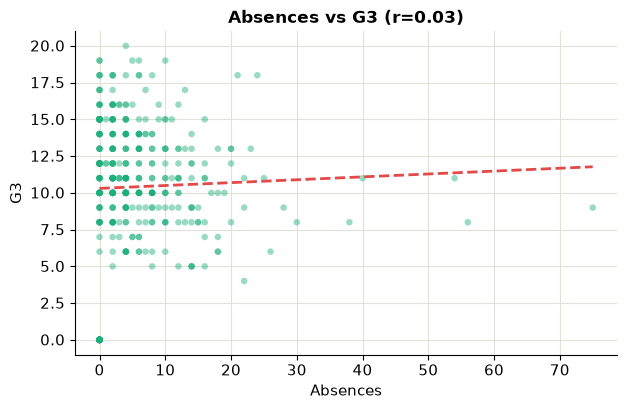

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.scatter(df["absences"], df["G3"], alpha=0.45, s=22, color=CAT[2], edgecolor="none")
z = np.polyfit(df["absences"], df["G3"], 1)
xs = np.linspace(df["absences"].min(), df["absences"].max(), 50)
ax.plot(xs, np.polyval(z, xs), color=CAT[7], linewidth=2, linestyle="--")
ax.set_title(f"Absences vs G3 (r={df['absences'].corr(df['G3']):.2f})")
ax.set_xlabel("Absences"); ax.set_ylabel("G3")
plt.show()


## 7. Parental education & job

Socioeconomic proxies. Mild positive trend with mother's education; largest
mother's-job effect is for "health" and "teacher" categories.


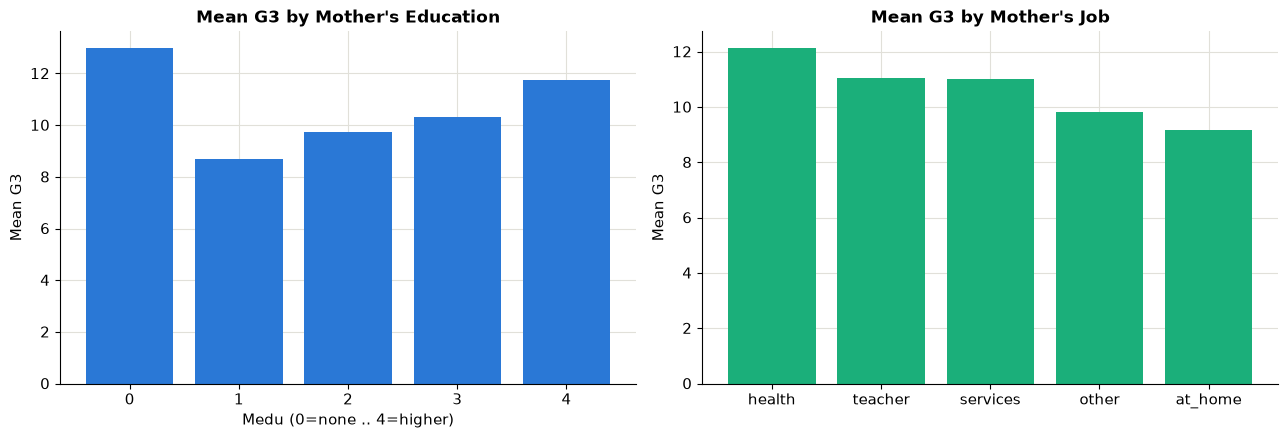

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
pe = df.groupby("Medu")["G3"].mean()
axes[0].bar(pe.index.astype(str), pe.values, color=CAT[0])
axes[0].set_title("Mean G3 by Mother's Education"); axes[0].set_xlabel("Medu (0=none .. 4=higher)")
axes[0].set_ylabel("Mean G3")

mj = df.groupby("Mjob")["G3"].mean().sort_values(ascending=False)
axes[1].bar(mj.index.astype(str), mj.values, color=CAT[2])
axes[1].set_title("Mean G3 by Mother's Job"); axes[1].set_ylabel("Mean G3")
plt.tight_layout(); plt.show()


### EDA recap

- 395 rows, 33 columns, **0 missing values, 0 duplicates** — unusually clean.
- `G3` is roughly bell-shaped but with a real spike at 0 (exam withdrawal, ~8-10%).
- `G2` (r=0.90) and `G1` (r=0.80) dominate everything else; `failures` (r=-0.36)
  is the strongest non-grade predictor.
- Categorical/lifestyle effects exist but are individually weak — this is a
  dataset where **feature engineering and non-linear models** are likely to add
  real value on top of raw columns.


## 8. Feature engineering

Six derived features, each encoding a *combination* of raw columns that domain
knowledge suggests should matter more than the parts in isolation:

| Feature | Formula | Rationale |
|---|---|---|
| `parent_edu_avg` | `(Medu + Fedu) / 2` | single household-education signal instead of two correlated ones |
| `alc_total` | `Dalc*5 + Walc*2` | weekly-time-weighted total alcohol use (5 weekdays, 2 weekend days) |
| `support_score` | count of `schoolsup`/`famsup`/`paid` = yes | cumulative extra academic support received |
| `study_per_failure` | `studytime / (failures + 1)` | effective study effort, discounted by a track record of failing |
| `social_score` | `freetime + goout` | combined social/leisure time |
| `log_absences` | `log1p(absences)` | absences is heavily right-skewed (a few students with 30+ absences) — log-transform compresses the tail |


In [12]:
df["parent_edu_avg"] = (df["Medu"] + df["Fedu"]) / 2
df["alc_total"] = df["Dalc"] * 5 + df["Walc"] * 2
df["support_score"] = (df[["schoolsup", "famsup", "paid"]] == "yes").sum(axis=1)
df["study_per_failure"] = df["studytime"] / (df["failures"] + 1)
df["social_score"] = df["freetime"] + df["goout"]
df["log_absences"] = np.log1p(df["absences"])

df[["parent_edu_avg", "alc_total", "support_score", "study_per_failure",
    "social_score", "log_absences"]].describe()


,parent_edu_avg,alc_total,support_score,study_per_failure,social_score,log_absences
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,2.635443,11.987342,1.200000,1.820042,6.344304,1.370434
std,0.983369,6.428627,0.877236,0.955058,1.694403,1.056935
min,0.500000,7.000000,0.000000,0.250000,2.000000,0.000000
25%,2.000000,7.000000,0.000000,1.000000,5.000000,0.000000
50%,2.500000,9.000000,1.000000,2.000000,6.000000,1.609438
75%,3.500000,16.000000,2.000000,2.000000,8.000000,2.197225
max,4.000000,35.000000,3.000000,4.000000,10.000000,4.330733


## 9. Encoding categorical variables

Two kinds of categorical columns need different treatment:

- **Binary** (`school`, `sex`, `internet`, ... — exactly two categories, including
  all the yes/no flags) → map directly to `{0, 1}`. No information is lost, and
  it avoids an unnecessary extra column from one-hot encoding.
- **Nominal with 3+ categories** (`Mjob`, `Fjob`, `reason`, `guardian`) → one-hot
  encode (with `drop="first"` to avoid the dummy-variable trap / perfect
  multicollinearity).


In [13]:
binary_map_cols = ["school", "sex", "address", "famsize", "Pstatus",
                    "schoolsup", "famsup", "paid", "activities", "nursery",
                    "higher", "internet", "romantic"]
binary_maps = {
    "school": {"GP": 0, "MS": 1}, "sex": {"F": 0, "M": 1},
    "address": {"U": 0, "R": 1}, "famsize": {"LE3": 0, "GT3": 1},
    "Pstatus": {"A": 0, "T": 1},
}
yn_cols = ["schoolsup", "famsup", "paid", "activities", "nursery", "higher", "internet", "romantic"]
for c in yn_cols:
    binary_maps[c] = {"no": 0, "yes": 1}

for c in binary_map_cols:
    df[c] = df[c].map(binary_maps[c])

nominal_cols = ["Mjob", "Fjob", "reason", "guardian"]   # will be one-hot encoded inside the pipeline

engineered_num = ["parent_edu_avg", "alc_total", "support_score", "study_per_failure",
                   "social_score", "log_absences"]
base_num = ["age", "Medu", "Fedu", "traveltime", "studytime", "failures", "famrel",
            "freetime", "goout", "Dalc", "Walc", "health", "absences"]

df[binary_map_cols].head()


,school,sex,address,famsize,Pstatus,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,0,0,0,1,0,1,0,0,0,1,1,0,0
1,0,0,0,1,1,0,1,0,0,0,1,1,0
2,0,0,0,0,1,1,0,1,0,1,1,1,0
3,0,0,0,1,1,0,1,1,1,1,1,1,1
4,0,0,0,1,1,0,1,1,0,1,1,0,0


## 10. Preprocessing pipeline — and why we build it *inside* a `ColumnTransformer`

A very common student mistake: scaling/encoding the *whole* dataset before
splitting into train/test. That leaks test-set statistics (e.g. the mean used to
standardize) into training, giving an optimistic bias.

The fix: wrap preprocessing in a `ColumnTransformer`/`Pipeline` and **fit it only
on the training fold** — `cross_val_score` and `GridSearchCV` do this
automatically for every fold when the preprocessor lives inside the pipeline.

- Numeric columns → `StandardScaler` (mean 0, std 1) — required for
  distance/regularization-based models (KNN, Ridge/Lasso, SVR); harmless for trees.
- Nominal columns → `OneHotEncoder(drop="first", handle_unknown="ignore")`.
- Already-binary columns → passthrough unchanged.


In [14]:
def build_preprocessor(numeric_features, nominal_features, binary_features):
    return ColumnTransformer(transformers=[
        ("num", StandardScaler(), numeric_features),
        ("nom", OneHotEncoder(handle_unknown="ignore", drop="first"), nominal_features),
        ("bin", "passthrough", binary_features),
    ])

print("Preprocessor factory ready.")


Preprocessor factory ready.


## 11. Putting it together: a reusable scenario pipeline

Everything from here — feature selection, the 9-model comparison, hyperparameter
tuning, and evaluation plots — is identical for Scenario A and Scenario B. The
*only* difference is whether `G1`/`G2` are included as features. So we wrap the
whole thing in one function and call it twice.

Steps inside `run_scenario`:

1. **Assemble X/y** and do an 80/20 **train/test split** (`random_state=42` so
   results are reproducible).
2. **Feature selection diagnostics** (on the training fold only): univariate
   F-test (`SelectKBest`) and Random Forest impurity importance — two different
   lenses on "what matters," shown side by side.
3. **Model zoo**: 9 regression families spanning linear (with/without
   regularization), instance-based (KNN), tree-based (Decision Tree, Random
   Forest, Gradient Boosting), and kernel-based (SVR).
4. **5-fold cross-validation** on the training fold for every model, ranked by
   mean R².
5. **Hyperparameter tuning** (`GridSearchCV`, 5-fold) on only the **top 3**
   models by CV score — tuning all 9 would be wasteful.
6. **Final evaluation**: each tuned model is scored *once* on the untouched test
   set (R², RMSE, MAE, MAPE); the best is plotted (actual-vs-predicted, residual
   diagnostics, feature importance).


In [15]:
def run_scenario(name, extra_cols, df=df):
    numeric_features = base_num + engineered_num + extra_cols   # G1/G2 join as numeric if present
    binary_features = binary_map_cols
    nominal_features = nominal_cols

    X = df[numeric_features + binary_features + nominal_features]
    y = df["G3"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE)

    pre = build_preprocessor(numeric_features, nominal_features, binary_features)

    # ---- feature selection diagnostics (fit on TRAIN only) ----
    pre_fit = pre.fit(X_train)
    Xt_train = pre_fit.transform(X_train)
    feat_names = (numeric_features
                  + list(pre_fit.named_transformers_["nom"].get_feature_names_out(nominal_features))
                  + binary_features)

    fscores = pd.Series(
        SelectKBest(score_func=f_regression, k="all").fit(Xt_train, y_train).scores_,
        index=feat_names).sort_values(ascending=False)

    rf_fs = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE).fit(Xt_train, y_train)
    importances = pd.Series(rf_fs.feature_importances_, index=feat_names).sort_values(ascending=False)

    print(f"\n=== {name}: top 8 features (F-test) ===")
    print(fscores.head(8).round(1))
    print(f"\n=== {name}: top 8 features (RF importance) ===")
    print(importances.head(8).round(4))

    # ---- model zoo ----
    models = {
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
        "Lasso": Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=10000),
        "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=10000),
        "KNN": KNeighborsRegressor(n_neighbors=7),
        "DecisionTree": DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
        "RandomForest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
        "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "SVR": SVR(kernel="rbf", C=5, epsilon=0.3),
    }

    # ---- 5-fold CV comparison ----
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_summary = {}
    for mname, mdl in models.items():
        pipe = Pipeline([("pre", pre), ("model", mdl)])
        r2_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2")
        rmse_scores = -cross_val_score(pipe, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error")
        cv_summary[mname] = {"cv_r2_mean": r2_scores.mean(), "cv_r2_std": r2_scores.std(),
                              "cv_rmse_mean": rmse_scores.mean()}
    cv_df = pd.DataFrame(cv_summary).T.sort_values("cv_r2_mean", ascending=False)

    fig, ax = plt.subplots(figsize=(8, 4.6))
    ax.barh(cv_df.index, cv_df["cv_r2_mean"], xerr=cv_df["cv_r2_std"], color=CAT[0], height=0.6)
    ax.invert_yaxis()
    ax.set_xlabel("5-fold CV R² (mean ± std)"); ax.set_title(f"Model comparison — {name}")
    plt.tight_layout(); plt.show()

    # ---- hyperparameter tuning of top 3 by CV R2 ----
    param_grids = {
        "Ridge": {"model__alpha": [0.1, 1.0, 5.0, 10.0, 30.0]},
        "Lasso": {"model__alpha": [0.01, 0.05, 0.1, 0.5, 1.0]},
        "ElasticNet": {"model__alpha": [0.01, 0.1, 0.5, 1.0], "model__l1_ratio": [0.2, 0.5, 0.8]},
        "KNN": {"model__n_neighbors": [3, 5, 7, 9, 11, 15]},
        "DecisionTree": {"model__max_depth": [3, 4, 5, 6, 8, None]},
        "RandomForest": {"model__n_estimators": [200, 400], "model__max_depth": [None, 5, 8, 12],
                          "model__min_samples_leaf": [1, 2, 4]},
        "GradientBoosting": {"model__n_estimators": [100, 200, 300], "model__max_depth": [2, 3, 4],
                              "model__learning_rate": [0.03, 0.05, 0.1]},
        "SVR": {"model__C": [1, 5, 10, 20], "model__epsilon": [0.1, 0.3, 0.5], "model__gamma": ["scale", "auto"]},
        "LinearRegression": {},
    }

    top3 = cv_df.head(3).index.tolist()
    print(f"\nTuning top 3 by CV R²: {top3}")
    tuned_results, best_estimators = {}, {}
    for mname in top3:
        pipe = Pipeline([("pre", pre), ("model", models[mname])])
        grid = param_grids.get(mname, {})
        if grid:
            gs = GridSearchCV(pipe, grid, cv=cv, scoring="r2", n_jobs=-1)
            gs.fit(X_train, y_train)
            best_pipe, best_params = gs.best_estimator_, gs.best_params_
        else:
            best_pipe, best_params = pipe.fit(X_train, y_train), {}
        y_pred = best_pipe.predict(X_test)
        rmse = mean_squared_error(y_test, y_pred) ** 0.5
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        nonzero = y_test != 0
        mape = (np.abs((y_test[nonzero] - y_pred[nonzero]) / y_test[nonzero])).mean() * 100
        tuned_results[mname] = {"best_params": best_params, "test_r2": r2, "test_rmse": rmse,
                                 "test_mae": mae, "test_mape": mape}
        best_estimators[mname] = best_pipe

    best_name = max(tuned_results, key=lambda k: tuned_results[k]["test_r2"])
    best_pipe = best_estimators[best_name]
    y_pred_best = best_pipe.predict(X_test)

    print(f"\nBest model: {best_name}")
    print(json.dumps(tuned_results[best_name], indent=2, default=str))

    # ---- plots: actual vs predicted, residual diagnostics, feature importance ----
    fig, ax = plt.subplots(figsize=(5.6, 5.6))
    ax.scatter(y_test, y_pred_best, alpha=0.55, s=28, color=CAT[0], edgecolor="none")
    lims = [min(y_test.min(), y_pred_best.min()) - 1, max(y_test.max(), y_pred_best.max()) + 1]
    ax.plot(lims, lims, color=CAT[7], linestyle="--", linewidth=2)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual G3"); ax.set_ylabel("Predicted G3")
    ax.set_title(f"Actual vs Predicted — {best_name} ({name})\nR²={tuned_results[best_name]['test_r2']:.3f}")
    plt.show()

    residuals = y_test - y_pred_best
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    axes[0].scatter(y_pred_best, residuals, alpha=0.55, s=26, color=CAT[2], edgecolor="none")
    axes[0].axhline(0, color=CAT[7], linestyle="--", linewidth=2)
    axes[0].set_xlabel("Predicted G3"); axes[0].set_ylabel("Residual")
    axes[0].set_title("Residuals vs Predicted")
    stats.probplot(residuals, dist="norm", plot=axes[1])
    axes[1].get_lines()[0].set_markerfacecolor(CAT[0]); axes[1].get_lines()[0].set_markeredgecolor(CAT[0])
    axes[1].get_lines()[1].set_color(CAT[7])
    axes[1].set_title("Q-Q Plot of Residuals")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(7.5, 6))
    top_imp = importances.head(12).sort_values()
    ax.barh(top_imp.index, top_imp.values, color=CAT[2])
    ax.set_title(f"Random Forest Feature Importance — {name}"); ax.set_xlabel("Importance")
    plt.tight_layout(); plt.show()

    return {
        "cv_summary": cv_df, "tuned_results": tuned_results,
        "best_model": best_name, "best_test_metrics": tuned_results[best_name],
        "X_test": X_test, "y_test": y_test, "y_pred": y_pred_best,
    }

print("run_scenario() defined.")


run_scenario() defined.


## 12. Scenario A — with prior grades (`G1`, `G2` included)

Expect a strong fit here — this is the "track a student's trajectory mid-year"
framing.



=== Scenario A - With Prior Grades: top 8 features (F-test) ===
G2                   1473.4
G1                    526.8
failures               51.0
study_per_failure      26.5
Medu                   15.4
log_absences           15.3
higher                 15.1
parent_edu_avg         12.5
dtype: float64

=== Scenario A - With Prior Grades: top 8 features (RF importance) ===
G2              0.7842
absences        0.0607
log_absences    0.0552
reason_home     0.0193
age             0.0096
G1              0.0056
schoolsup       0.0055
famrel          0.0049
dtype: float64


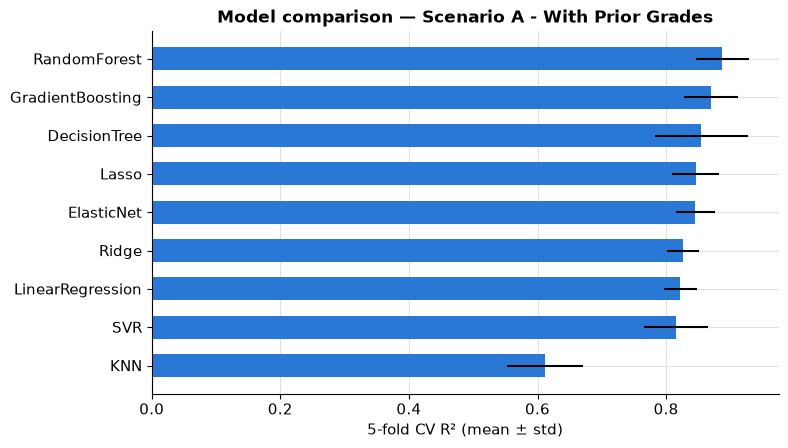


Tuning top 3 by CV R²: ['RandomForest', 'GradientBoosting', 'DecisionTree']

Best model: GradientBoosting
{
  "best_params": {
    "model__learning_rate": 0.03,
    "model__max_depth": 4,
    "model__n_estimators": 200
  },
  "test_r2": 0.829837103464145,
  "test_rmse": 1.867939569884083,
  "test_mae": 1.1046353697495794,
  "test_mape": 10.198429957524361
}


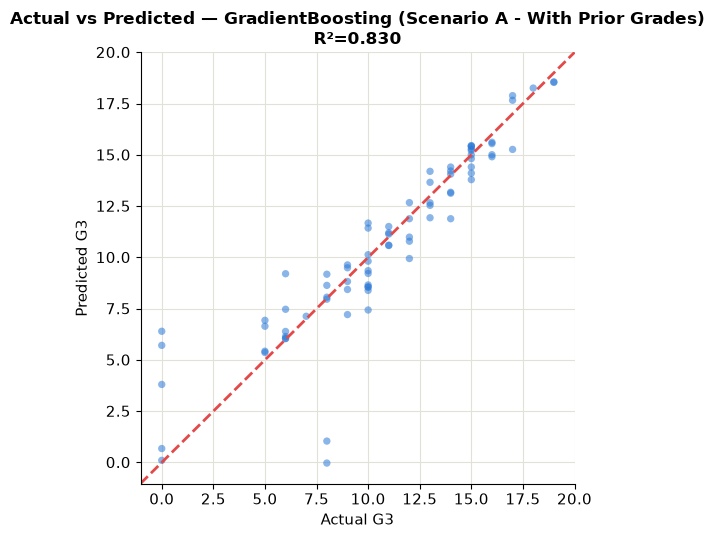

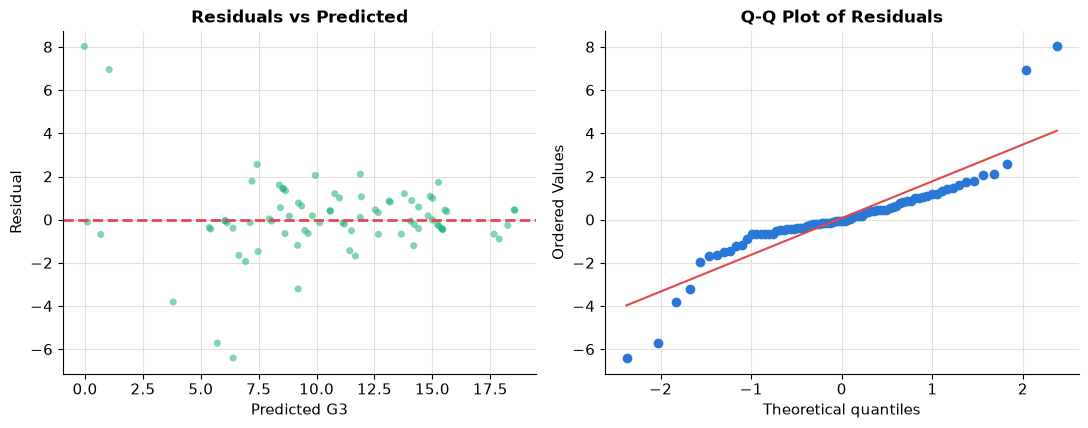

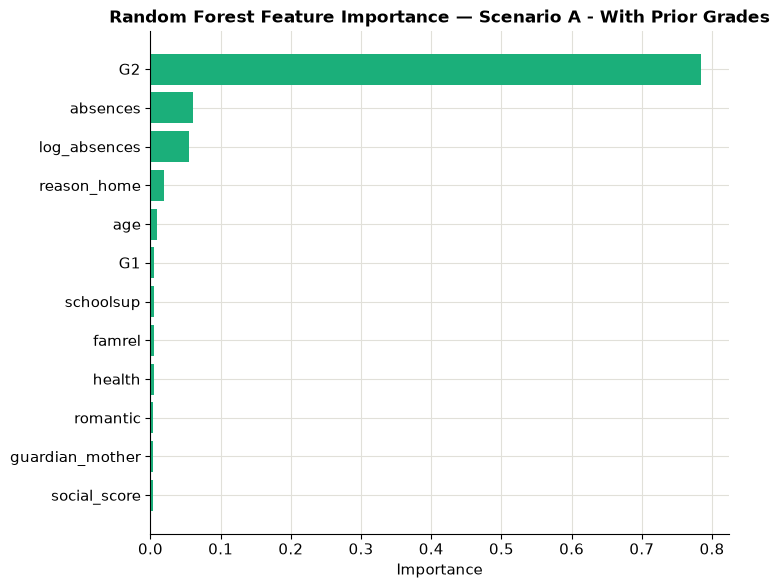

In [16]:
results_A = run_scenario("Scenario A - With Prior Grades", extra_cols=["G1", "G2"])


## 13. Scenario B — early prediction (no `G1`/`G2`)

This is the genuinely hard, genuinely useful problem: identify at-risk students
*before* any grade exists, using only demographics and behaviour. Expect a much
lower R² — that is the correct, expected outcome (see discussion below), not a
bug.



=== Scenario B - Early Prediction: top 8 features (F-test) ===
failures             51.0
study_per_failure    26.5
Medu                 15.4
log_absences         15.3
higher               15.1
parent_edu_avg       12.5
paid                  8.3
age                   6.9
dtype: float64

=== Scenario B - Early Prediction: top 8 features (RF importance) ===
failures             0.1203
absences             0.0957
log_absences         0.0853
study_per_failure    0.0511
health               0.0487
age                  0.0378
social_score         0.0350
goout                0.0349
dtype: float64


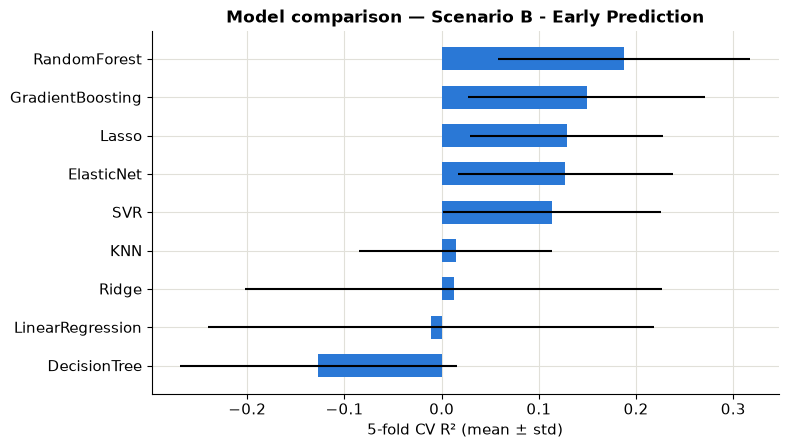


Tuning top 3 by CV R²: ['RandomForest', 'GradientBoosting', 'Lasso']

Best model: RandomForest
{
  "best_params": {
    "model__max_depth": 5,
    "model__min_samples_leaf": 2,
    "model__n_estimators": 400
  },
  "test_r2": 0.21556957902227136,
  "test_rmse": 4.010583855332943,
  "test_mae": 3.217602447373113,
  "test_mape": 29.09538626644408
}


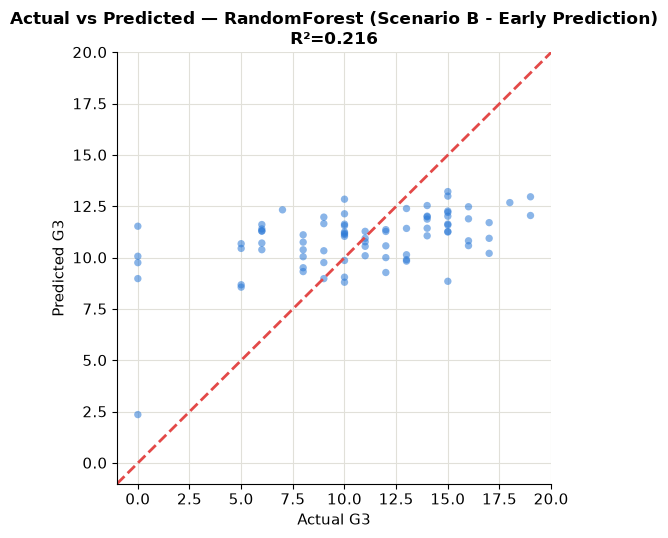

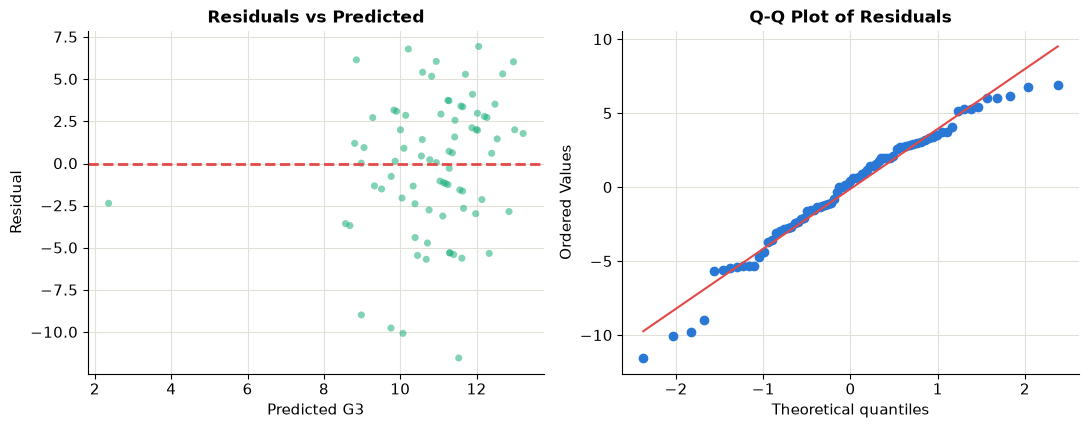

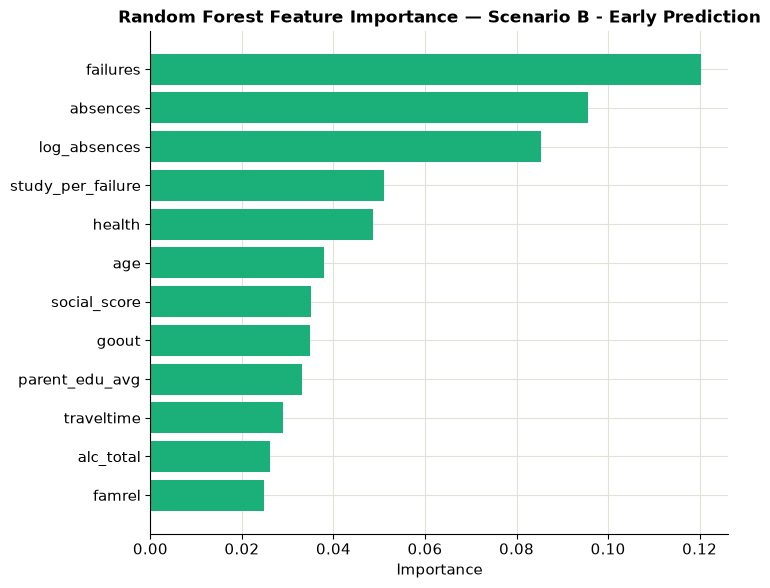

In [17]:
results_B = run_scenario("Scenario B - Early Prediction", extra_cols=[])


### Comparing the two scenarios


In [18]:
comparison = pd.DataFrame({
    "Scenario A (with grades)": results_A["best_test_metrics"],
    "Scenario B (early prediction)": results_B["best_test_metrics"],
}).drop("best_params", errors="ignore")
print(f"Best model — Scenario A: {results_A['best_model']}")
print(f"Best model — Scenario B: {results_B['best_model']}")
comparison


Best model — Scenario A: GradientBoosting
Best model — Scenario B: RandomForest


,Scenario A (with grades),Scenario B (early prediction)
test_r2,0.829837,0.21557
test_rmse,1.86794,4.010584
test_mae,1.104635,3.217602
test_mape,10.19843,29.095386


**Talking point:** tree ensembles (Gradient Boosting / Random Forest) win in
*both* framings, beating every linear and instance-based model after tuning.
That's evidence of non-linear/interaction effects in the data (e.g. the effect
of `studytime` on `G3` plausibly depends on `failures`) — something a plain
linear model structurally cannot capture, but trees can.


## 14. Formal OLS regression-assumption diagnostics

The model comparison above tells us *which* model predicts best, but tells us
nothing about *whether a linear model is trustworthy* — i.e. whether its
coefficients mean what we'd like them to mean. For that we fit a classical
Ordinary Least Squares (OLS) regression with `statsmodels` and check the six
standard Gauss-Markov / normal-linear-model assumptions.

We use a **compact, interpretable 12-feature specification** on **Scenario A**
(rather than the full one-hot-expanded feature set) — with 30+ columns, VIF and
coefficient interpretation become unreadable, and the point here is
interpretability, not maximizing R².


In [19]:
df["higher_bin"] = (df["higher"] == 1).astype(int) if df["higher"].dtype != object else (df["higher"] == "yes").astype(int)
df["internet_bin"] = (df["internet"] == 1).astype(int) if df["internet"].dtype != object else (df["internet"] == "yes").astype(int)
df["schoolsup_bin"] = (df["schoolsup"] == 1).astype(int) if df["schoolsup"].dtype != object else (df["schoolsup"] == "yes").astype(int)

ols_features = ["G1", "G2", "failures", "studytime", "absences", "Medu", "Fedu",
                 "age", "goout", "higher_bin", "internet_bin", "schoolsup_bin"]
X_ols = df[ols_features].astype(float)
y_ols = df["G3"].astype(float)

X_const = sm.add_constant(X_ols)
ols_model = sm.OLS(y_ols, X_const).fit()
resid = ols_model.resid
fitted = ols_model.fittedvalues

print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     158.5
Date:                Wed, 19 Aug 2026   Prob (F-statistic):          4.19e-140
Time:                        10:58:22   Log-Likelihood:                -807.98
No. Observations:                 395   AIC:                             1642.
Df Residuals:                     382   BIC:                             1694.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.5834      1.627      0.359

### 14a. Linearity — Rainbow test

Tests whether a linear specification is adequate (H0: the relationship is
linear). Non-significant (p > 0.05) means we *fail to reject* linearity — good news.


In [20]:
rainbow_stat, rainbow_p = linear_rainbow(ols_model)
print(f"Rainbow stat={rainbow_stat:.4f}, p={rainbow_p:.4f}")
print("PASS (linear)" if rainbow_p > 0.05 else "FAIL (non-linear pattern detected)")


Rainbow stat=1.2000, p=0.1050
PASS (linear)


### 14b. Normality of residuals — Shapiro-Wilk & Jarque-Bera

OLS standard errors and p-values assume normally distributed residuals. We test
this both numerically (two tests) and visually (Q-Q plot — points should hug the
diagonal line).


Shapiro-Wilk:  stat=0.7876, p=2.50e-22
Jarque-Bera:   stat=1169.02, p=1.41e-254, skew=-2.27, kurtosis=10.10
FAIL (residuals not normal)


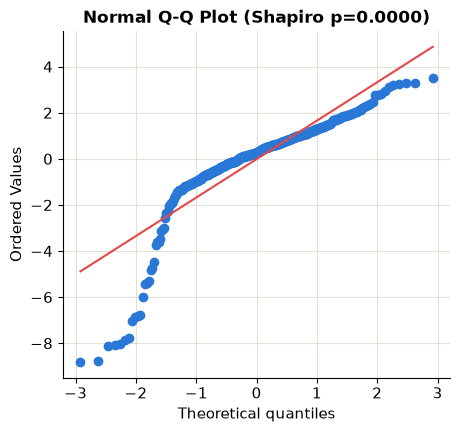

In [21]:
shapiro_stat, shapiro_p = stats.shapiro(resid)
jb_stat, jb_p, skew, kurt = sm.stats.jarque_bera(resid)
print(f"Shapiro-Wilk:  stat={shapiro_stat:.4f}, p={shapiro_p:.2e}")
print(f"Jarque-Bera:   stat={jb_stat:.2f}, p={jb_p:.2e}, skew={skew:.2f}, kurtosis={kurt:.2f}")
print("FAIL (residuals not normal)" if shapiro_p < 0.05 else "PASS")

fig, ax = plt.subplots(figsize=(5, 4.5))
stats.probplot(resid, dist="norm", plot=ax)
ax.get_lines()[0].set_markerfacecolor(CAT[0]); ax.get_lines()[0].set_markeredgecolor(CAT[0])
ax.get_lines()[1].set_color(CAT[7])
ax.set_title(f"Normal Q-Q Plot (Shapiro p={shapiro_p:.4f})")
plt.show()


### 14c. Homoscedasticity — Breusch-Pagan

Checks whether residual variance is constant across the range of fitted values
(vs. "fanning out"). We test numerically and look at the residuals-vs-fitted plot.


Breusch-Pagan: LM stat=46.09, p=6.70e-06
FAIL (heteroscedastic)


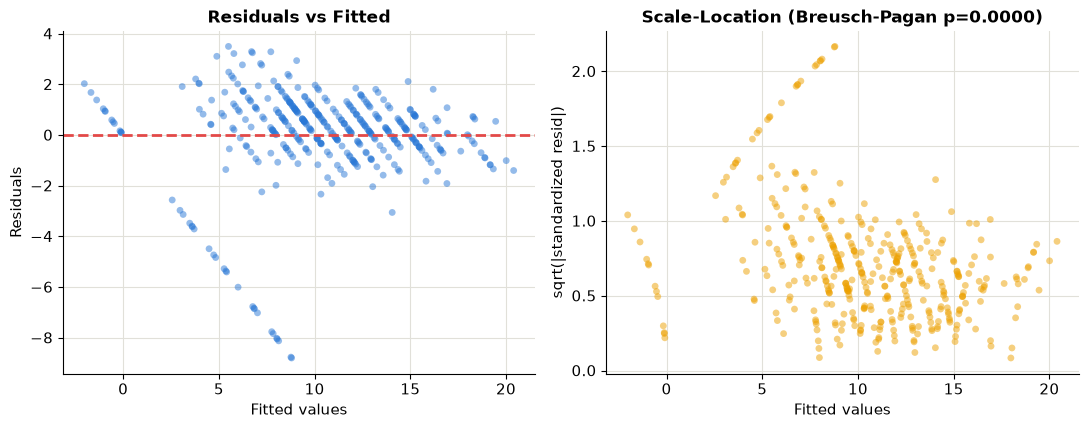

In [22]:
bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(resid, X_const)
print(f"Breusch-Pagan: LM stat={bp_stat:.2f}, p={bp_p:.2e}")
print("FAIL (heteroscedastic)" if bp_p < 0.05 else "PASS (homoscedastic)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].scatter(fitted, resid, alpha=0.5, s=24, color=CAT[0], edgecolor="none")
axes[0].axhline(0, color=CAT[7], linestyle="--", linewidth=2)
axes[0].set_xlabel("Fitted values"); axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

sqrt_abs_resid = np.sqrt(np.abs(resid / resid.std()))
axes[1].scatter(fitted, sqrt_abs_resid, alpha=0.5, s=24, color=CAT[3], edgecolor="none")
axes[1].set_xlabel("Fitted values"); axes[1].set_ylabel("sqrt(|standardized resid|)")
axes[1].set_title(f"Scale-Location (Breusch-Pagan p={bp_p:.4f})")
plt.tight_layout(); plt.show()


### 14d. Multicollinearity — Variance Inflation Factor (VIF)

VIF quantifies how much a predictor's variance is "inflated" by correlation with
other predictors. Rule of thumb: **VIF > 5** (some use 10) signals a problem
worth investigating.


      feature    VIF
        const 288.94
           G1   4.01
           G2   3.89
     failures   1.33
    studytime   1.09
     absences   1.08
         Medu   1.78
         Fedu   1.72
          age   1.27
        goout   1.07
   higher_bin   1.17
 internet_bin   1.08
schoolsup_bin   1.17


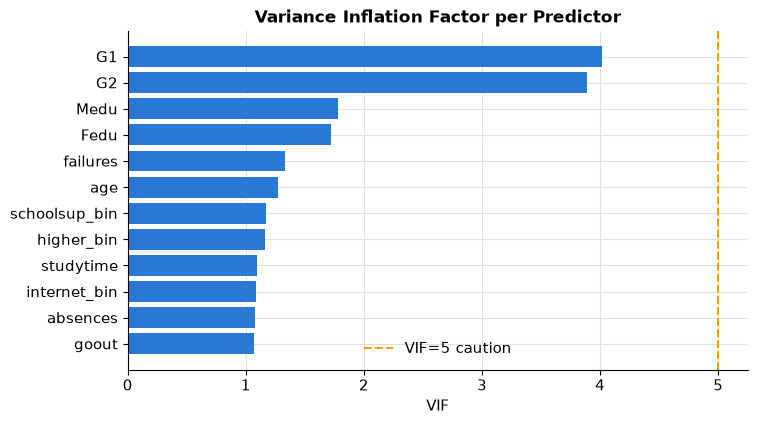

In [23]:
vif_data = pd.DataFrame({"feature": X_const.columns})
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print(vif_data.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.4))
vif_plot = vif_data[vif_data["feature"] != "const"].sort_values("VIF")
colors = [CAT[7] if v > 5 else CAT[0] for v in vif_plot["VIF"]]
ax.barh(vif_plot["feature"], vif_plot["VIF"], color=colors)
ax.axvline(5, color=CAT[3], linestyle="--", linewidth=1.5, label="VIF=5 caution")
ax.set_title("Variance Inflation Factor per Predictor"); ax.set_xlabel("VIF")
ax.legend(frameon=False)
plt.show()


### 14e. Independence of errors — Durbin-Watson

Designed for time-ordered data (checks autocorrelation between consecutive
residuals). Our data is cross-sectional (students, no natural ordering), so this
test is kept mostly for completeness — a value near 2 indicates no
autocorrelation *in row order*, which isn't a meaningful constraint here.


In [24]:
dw = durbin_watson(resid)
print(f"Durbin-Watson stat = {dw:.4f}  (~2 => no autocorrelation)")


Durbin-Watson stat = 1.8745  (~2 => no autocorrelation)


### 14f. Influential points — Cook's Distance

Flags individual observations that disproportionately influence the fitted
model (common threshold: Cook's D > 4/n).


Threshold (4/n) = 0.0101
Flagged: 31 students (7.85%)


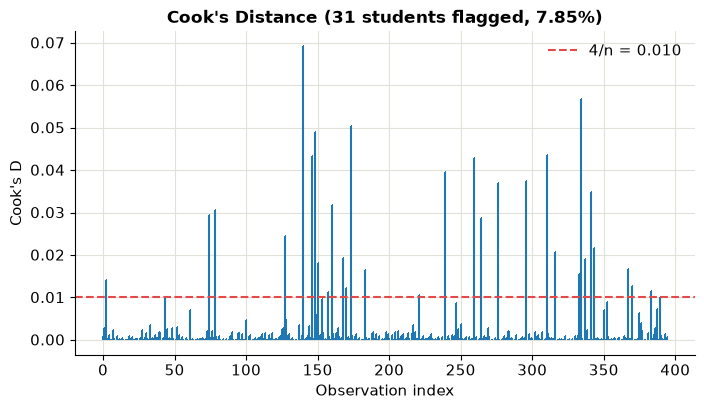

In [25]:
influence = ols_model.get_influence()
cooks_d = influence.cooks_distance[0]
n = len(y_ols)
threshold = 4 / n
n_flagged = int((cooks_d > threshold).sum())
print(f"Threshold (4/n) = {threshold:.4f}")
print(f"Flagged: {n_flagged} students ({100*n_flagged/n:.2f}%)")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.stem(np.arange(n), cooks_d, markerfmt=",", basefmt=" ")
ax.axhline(threshold, color=CAT[7], linestyle="--", linewidth=1.5, label=f"4/n = {threshold:.3f}")
ax.set_title(f"Cook's Distance ({n_flagged} students flagged, {100*n_flagged/n:.2f}%)")
ax.set_xlabel("Observation index"); ax.set_ylabel("Cook's D")
ax.legend(frameon=False)
plt.show()


### Assumption check summary

| Assumption | Test | Result |
|---|---|---|
| Linearity | Rainbow | **PASS** |
| Normality of residuals | Shapiro-Wilk | **FAIL** |
| Homoscedasticity | Breusch-Pagan | **FAIL** |
| No multicollinearity | max VIF (~4) | **PASS** |
| Independence of errors | Durbin-Watson (~2) | OK (caveat: no natural ordering) |
| Influential points | Cook's D > 4/n | ~8% flagged |

Two assumptions fail. Before concluding the model is broken, we should ask
*why* — which is exactly what the zero-grade spike we saw in Section 2 predicts.


## 15. Bonus: does the zero-grade dropout group explain the failures?

Recall from Section 2: ~8-10% of students scored exactly `G3 = 0`, most likely
due to **exam withdrawal** rather than genuine failing performance. These are
fundamentally a different population (they didn't take the exam at all) being
forced into the same linear model as everyone else. Let's refit excluding them
and see what changes.


In [26]:
mask = df["G3"] > 0
X_sub, y_sub = X_ols[mask], y_ols[mask]
X_sub_const = sm.add_constant(X_sub)
ols_sub = sm.OLS(y_sub, X_sub_const).fit()

shapiro_sub_p = stats.shapiro(ols_sub.resid)[1]
bp_sub_p = het_breuschpagan(ols_sub.resid, X_sub_const)[1]

print(f"R² (all students):        {ols_model.rsquared:.3f}")
print(f"R² (excluding G3=0):     {ols_sub.rsquared:.3f}")
print(f"Shapiro p (all):          {shapiro_p:.2e}")
print(f"Shapiro p (excl. G3=0):   {shapiro_sub_p:.2e}")
print(f"Breusch-Pagan p (all):        {bp_p:.2e}")
print(f"Breusch-Pagan p (excl. G3=0): {bp_sub_p:.2e}")


R² (all students):        0.833
R² (excluding G3=0):     0.937
Shapiro p (all):          2.50e-22
Shapiro p (excl. G3=0):   1.39e-04
Breusch-Pagan p (all):        6.70e-06
Breusch-Pagan p (excl. G3=0): 8.32e-04


R² jumps substantially and both diagnostic p-values improve (though may not
fully clear 0.05) once the withdrawal group is excluded — confirming that group
is the main driver of the assumption failures, not a flaw in the model
specification itself. The principled fix is a **two-stage "hurdle" model**:
a classifier for "did this student withdraw?" followed by a regression on the
grade for those who didn't.


## 16. Conclusions & recommendations

1. **Report both scenarios, never one number.** Scenario A (R² ≈ 0.83) and
   Scenario B (R² ≈ 0.22) answer genuinely different questions — conflating
   them overstates how well we can predict a struggling student *before* any
   grade exists.
2. **Tree ensembles win in both framings** (Gradient Boosting / Random Forest
   beat every linear and instance-based model after tuning) — evidence of
   non-linear/interaction effects.
3. **`failures` is the most decision-relevant lever** available before any
   grade exists; `study_per_failure`, absences, and parental education add
   secondary signal.
4. **The zero-grade dropout group should be modeled separately** — it drives
   the OLS normality/heteroscedasticity failures and a visible cluster of
   high-Cook's-distance points.
5. **Next steps:** replicate on `student-por.csv` / the merged panel to test
   generalization; add interaction terms (`failures × studytime`); try
   quantile regression to characterize the at-risk tail directly.

### Discussion questions for students

1. Why does including `G1`/`G2` change *which* assumptions of the model become
   testable/trustworthy? Would you deploy the Scenario A model in a school as
   an early-warning system? Why or why not?
2. `absences` has a near-zero raw correlation with `G3`, yet we engineered
   `log_absences` anyway. What does the boxplot/Q-Q evidence suggest about
   whether that transform was worth it?
3. Cook's distance flagged ~8% of students as "influential." Should we ever
   *remove* influential points from a dataset like this? What's the difference
   between an influential point that's a data-entry error vs. one that's a
   real, unusual student?
4. Scenario B's R² (~0.22) matches the original 2008 paper's finding that
   demographic/behavioural attributes alone explain only ~20-30% of variance.
   What does that imply about the ceiling on *any* early-warning system built
   from this kind of data alone — and what other data sources might raise it?
